# アントコロニー最適化（巡回セールスマン問題）

## インストールが必要なライブラリ
インストールは一度だけ行えば再度行う必要ない

acopyのインストール

In [1]:
!pip install acopy

NetworkXのインストール

In [2]:
!pip install tqdm

## ライブラリのインポート

In [3]:
import numpy as np
import random
import math
import networkx as nx
import acopy
import matplotlib.pyplot as plt

## ライブラリを使う準備
・rho：フェロモンの蒸発率<br>
・q：１匹のアリが経路に置くフェロモンの合計値<br>
・alpha：フェロモンの重要度<br>
・beta：ヒューリスティックな値（各地点間の経路長）の重要度

In [4]:
solver = acopy.Solver(rho=.03, q=1)
colony = acopy.Colony(alpha=1, beta=3)

## 経由地の設定

(1)位置で指定

以下のいづれかを実行

(1)-1 ランダムに配置

In [17]:
MAX_CITY = 20
random.seed(1)
cities = [(random.uniform(-1,1),random.uniform(-1,1)) for i in range(MAX_CITY)]

(1)-2 円形に配置

In [4]:
MAX_CITY = 10
cities = [(math.cos(math.pi*2*i/MAX_CITY),math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]

NetworkXを使って設定

In [18]:
G = nx.Graph()
for i in range(MAX_CITY):
    G.add_node(i,pos=(cities[i][0],cities[i][1]))
    
for i in range(MAX_CITY):
    for j  in range(i+1,MAX_CITY):
        G.add_edge(i, j, weight= np.sqrt((cities[i][0]-cities[j][0])**2+(cities[i][1]-cities[j][1])**2))

(2) 距離で指定

位置は円環上に並ぶように配置しておく

In [5]:
MAX_CITY = 5
cities = [(math.cos(math.pi*2*i/MAX_CITY),math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]

dist = [
    [math.inf, 5, 9, 8, 3],
    [0, math.inf, 8, 4, 7],
    [0, 0, math.inf, 4, 6],
    [0, 0, 0, math.inf, 5],
    [0, 0, 0, 0, math.inf],
]
G = nx.Graph()
for i in range(MAX_CITY):
    G.add_node(i,pos=(cities[i][0],cities[i][1]))
    
for i in range(MAX_CITY):
    for j  in range(i+1,MAX_CITY):
        G.add_edge(i, j, weight= dist[i][j])


## 場所の可視化

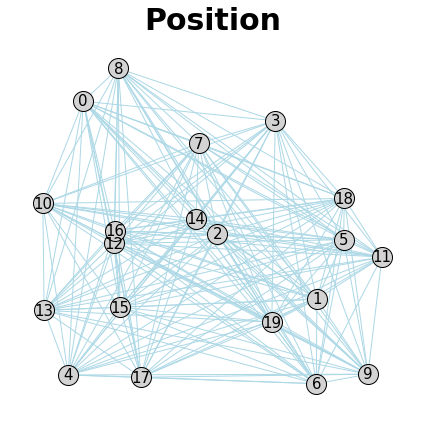

In [19]:
pos=nx.get_node_attributes(G,'pos')
#path = tour.path

fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Position", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
#nx.draw_networkx_edge_labels(G, pos, edge_labels)
#nx.draw_networkx( G, pos, with_labels=False, edgelist=path, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("Position.pdf")
plt.show()

## 探索の実行
limit:繰り返しの上限数

In [20]:
tour = solver.solve(G, colony, limit=200)

## 結果の表示
経路

In [21]:
print(f"path: {tour.nodes}")

path: [0, 8, 7, 3, 18, 5, 11, 9, 6, 19, 1, 2, 14, 16, 12, 15, 17, 4, 13, 10]


距離

In [22]:
print(f"cost: {tour.cost}")

cost: 8.34653307890112


In [23]:
tour.path#経路をエッジで表示

[(0, 8),
 (8, 7),
 (7, 3),
 (3, 18),
 (18, 5),
 (5, 11),
 (11, 9),
 (9, 6),
 (6, 19),
 (19, 1),
 (1, 2),
 (2, 14),
 (14, 16),
 (16, 12),
 (12, 15),
 (15, 17),
 (17, 4),
 (4, 13),
 (13, 10),
 (10, 0)]

## 経路の可視化（アントコロニー最適化）

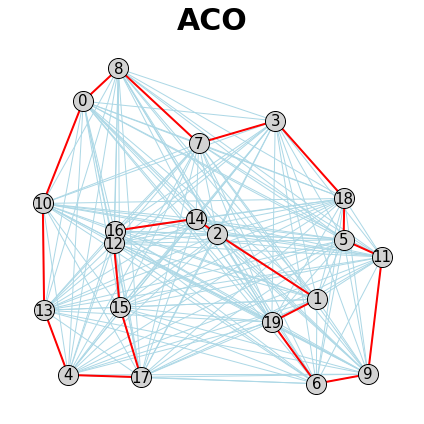

In [24]:
pos=nx.get_node_attributes(G,'pos')
path = tour.path

#pos = nx.spring_layout(G, seed=6)
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("ACO", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
#nx.draw_networkx_edge_labels(G, pos, edge_labels)
nx.draw_networkx( G, pos, with_labels=False, edgelist=path, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("ACO.pdf")
plt.show()

# NetworkXを用いた巡回セールスマン問題

In [25]:
tsp = nx.approximation.traveling_salesman_problem
path = tsp(G, cycle=True)

経路をNetworkXで表示しやすくするための処理

In [26]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

## 経路の可視化

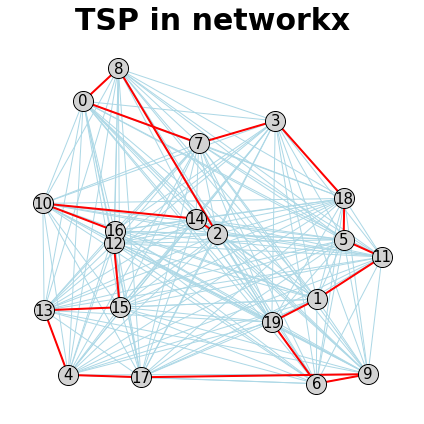

In [27]:
pos=nx.get_node_attributes(G,'pos')
path = edge_list

#pos = nx.spring_layout(G, seed=6)
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("TSP in networkx", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
#nx.draw_networkx_edge_labels(G, pos, edge_labels)
nx.draw_networkx( G, pos, with_labels=False, edgelist=path, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("TSP_in_networkx.pdf")
plt.show()

# NetworkXを用いた巡回セールスマン問題（アニーリング法）

In [28]:
SA_tsp = nx.approximation.simulated_annealing_tsp
method = lambda G, wt: SA_tsp(G, "greedy", weight=wt, temp=500)
path = tsp(G, cycle=True, method=method)

経路をNetworkXで表示しやすくするための処理

In [29]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

## 経路の可視化

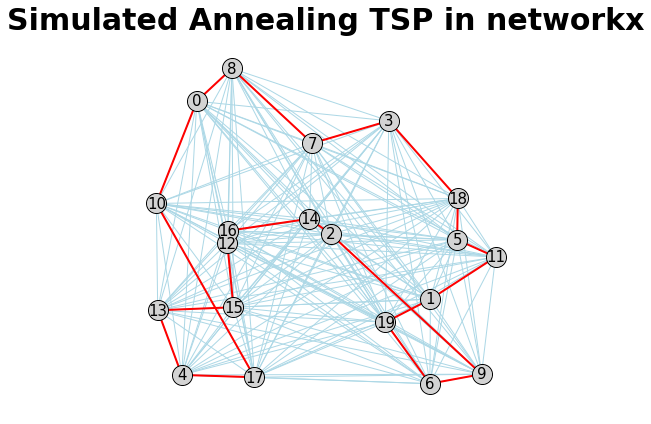

In [30]:
pos=nx.get_node_attributes(G,'pos')
path = edge_list

#pos = nx.spring_layout(G, seed=6)
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Simulated Annealing TSP in networkx", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
#nx.draw_networkx_edge_labels(G, pos, edge_labels)
nx.draw_networkx( G, pos, with_labels=False, edgelist=path, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("Simulated_Annealing_TSP_in_networkx.pdf")
plt.show()